In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/final_merge.csv")

df = df.drop(columns=[col for col in df.columns if "Unnamed" in col or col == "index"])

df["archive_date"] = pd.to_datetime(df["archive_date"], format="%d.%m.%Y")
df = df.sort_values("archive_date")

Matplotlib is building the font cache; this may take a moment.


In [4]:
tickers = ["USO", "XLE", "XOM", "CVX", "BP", "SHEL"]

print(df["market_ticker"].unique())

df = df[df["market_ticker"].isin(tickers)]

df["returns"] = df.groupby("market_ticker")["market_close"].pct_change()

df["returns_t+1"] = df.groupby("market_ticker")["returns"].shift(-1)

<StringArray>
['XOM', 'CVX', 'BP', 'SHEL', 'XLE', 'USO']
Length: 6, dtype: str


In [5]:
for ticker in tickers:
    sub = df[df["market_ticker"] == ticker]

    corr = sub[["fin_pos_share", "fin_neg_share", "returns_t+1"]].corr()
    print()
    print(f"{ticker}")
    print(corr)


USO
               fin_pos_share  fin_neg_share  returns_t+1
fin_pos_share       1.000000      -0.857670     0.001197
fin_neg_share      -0.857670       1.000000     0.027764
returns_t+1         0.001197       0.027764     1.000000

XLE
               fin_pos_share  fin_neg_share  returns_t+1
fin_pos_share       1.000000      -0.857670     0.038193
fin_neg_share      -0.857670       1.000000    -0.136649
returns_t+1         0.038193      -0.136649     1.000000

XOM
               fin_pos_share  fin_neg_share  returns_t+1
fin_pos_share       1.000000      -0.857670     0.002563
fin_neg_share      -0.857670       1.000000     0.015781
returns_t+1         0.002563       0.015781     1.000000

CVX
               fin_pos_share  fin_neg_share  returns_t+1
fin_pos_share       1.000000      -0.857670     0.000828
fin_neg_share      -0.857670       1.000000     0.012661
returns_t+1         0.000828       0.012661     1.000000

BP
               fin_pos_share  fin_neg_share  returns_t+1
fin_pos

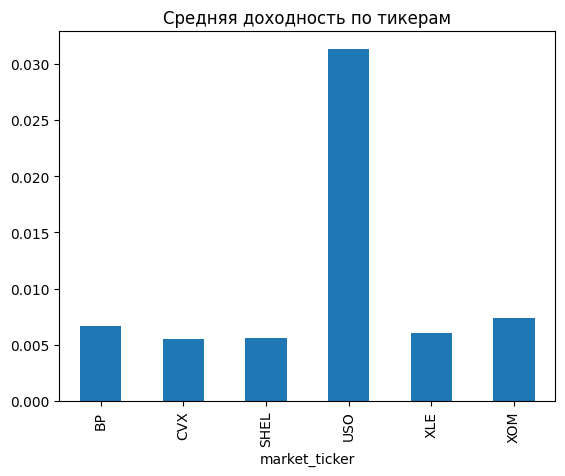

In [7]:
df.groupby("market_ticker")["returns_t+1"].mean().plot(kind="bar")
plt.title("Средняя доходность по тикерам")
plt.show()

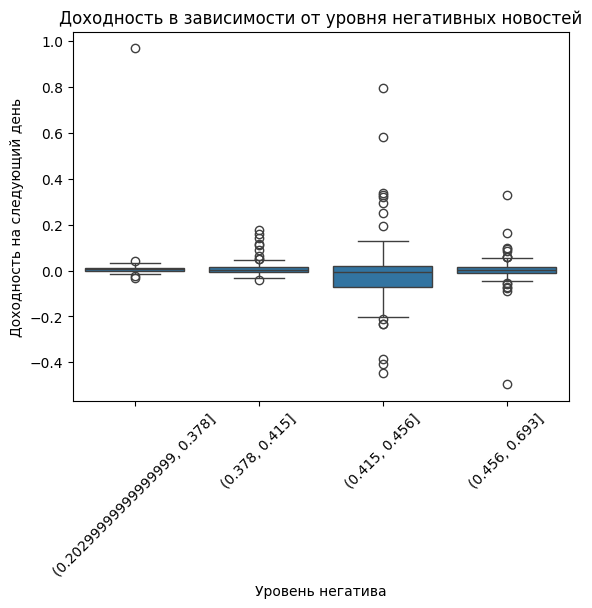

In [8]:
df["neg_group"] = pd.qcut(df["fin_neg_share"], q=4)

sns.boxplot(
    x="neg_group",
    y="returns_t+1",
    data=df
)

plt.title("Доходность в зависимости от уровня негативных новостей")
plt.xlabel("Уровень негатива")
plt.ylabel("Доходность на следующий день")

plt.xticks(rotation=45)
plt.show()

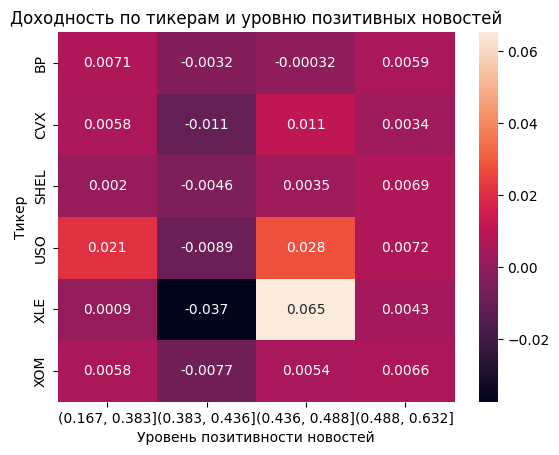

In [9]:
df["pos_group"] = pd.qcut(df["fin_pos_share"], q=4)

pivot = df.pivot_table(
    values="returns_t+1",
    index="market_ticker",
    columns="pos_group",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True)
plt.title("Доходность по тикерам и уровню позитивных новостей")
plt.xlabel("Уровень позитивности новостей")
plt.ylabel("Тикер")
plt.show()

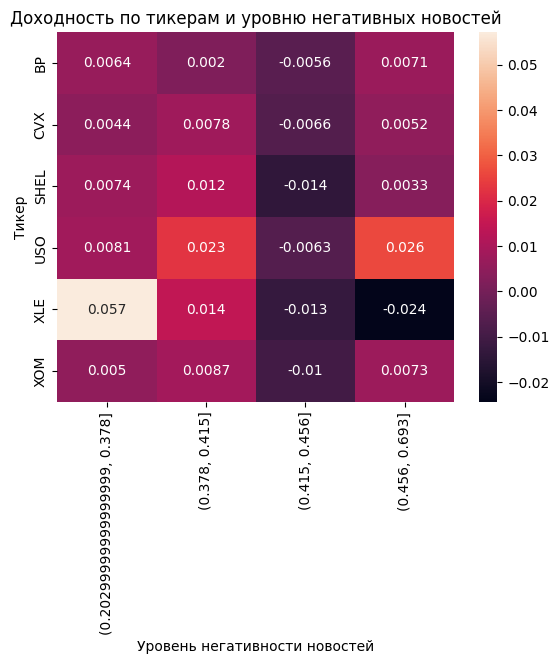

In [10]:
df["neg_group"] = pd.qcut(df["fin_neg_share"], q=4)

pivot = df.pivot_table(
    values="returns_t+1",
    index="market_ticker",
    columns="neg_group",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True)
plt.title("Доходность по тикерам и уровню негативных новостей")
plt.xlabel("Уровень негативности новостей")
plt.ylabel("Тикер")
plt.show()

In [11]:
high_neg = df[df["fin_neg_share"] > df["fin_neg_share"].quantile(0.9)]
low_neg = df[df["fin_neg_share"] < df["fin_neg_share"].quantile(0.1)]

print("High negative:", high_neg["returns_t+1"].mean())
print("Low negative:", low_neg["returns_t+1"].mean())

High negative: 0.015220665855559727
Low negative: 0.030771894958677576


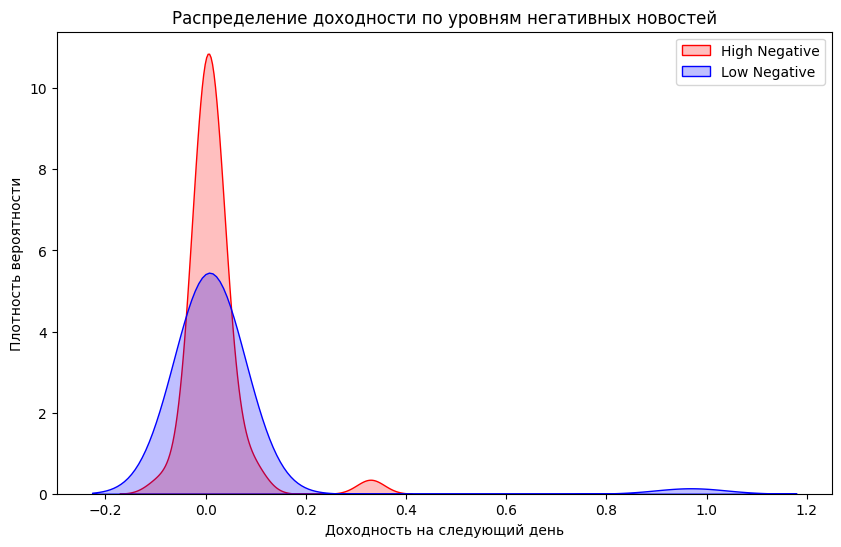

In [17]:
plt.figure(figsize=(10, 6))

sns.kdeplot(high_neg["returns_t+1"], color='red', label='High Negative', fill=True)
sns.kdeplot(low_neg["returns_t+1"], color='blue', label='Low Negative', fill=True)

plt.title('Распределение доходности по уровням негативных новостей')
plt.xlabel('Доходность на следующий день')
plt.ylabel('Плотность вероятности')
plt.legend()

plt.show()